# HireSafe – XGBoost Model

This notebook trains an XGBoost classifier on the HireSafe dataset.
It is part of the multi-model comparison study where **Random Forest** achieves the highest accuracy and is used in production.

In [1]:
!pip install imbalanced-learn xgboost

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

## 1. Load Dataset

In [3]:
df = pd.read_csv("hiresafe_ml_dataset.csv")
df.head()

,industry,country,layoff_count,workforce_percentage,total_funding_million_usd,stock_price_change_7d,revenue_growth_percent,market_cap_billion_usd,ai_automation_flag,year,hiring_status,company_size_encoded
0,Finance,USA,86,8.15,1560.48,-3.99,-8.75,298.47,0,2023,Hiring,0
1,Finance,Singapore,26,14.01,290.02,-4.28,6.20,325.48,0,2020,Hiring,1
2,Finance,Germany,213,8.09,370.89,4.60,-34.19,152.19,0,2022,Hiring,2
3,Retail,Singapore,350,21.47,802.72,-9.14,8.33,23.43,0,2024,Slowdown,1
4,Tech,UK,410,21.06,1186.87,0.01,-12.26,23.32,1,2024,Hiring,1


## 2. Assign Hiring Status Label

In [4]:
def assign_status(row):
    if row["workforce_percentage"] > 18:
        return "Slowdown"
    elif row["workforce_percentage"] > 8:
        return "Freeze"
    elif row["revenue_growth_percent"] > 2:
        return "Hiring"
    else:
        return "Freeze"

df["hiring_status"] = df.apply(assign_status, axis=1)

# Remove leakage feature
df = df.drop(columns=["workforce_percentage"])
df.head()

,industry,country,layoff_count,total_funding_million_usd,stock_price_change_7d,revenue_growth_percent,market_cap_billion_usd,ai_automation_flag,year,hiring_status,company_size_encoded
0,Finance,USA,86,1560.48,-3.99,-8.75,298.47,0,2023,Freeze,0
1,Finance,Singapore,26,290.02,-4.28,6.20,325.48,0,2020,Freeze,1
2,Finance,Germany,213,370.89,4.60,-34.19,152.19,0,2022,Freeze,2
3,Retail,Singapore,350,802.72,-9.14,8.33,23.43,0,2024,Slowdown,1
4,Tech,UK,410,1186.87,0.01,-12.26,23.32,1,2024,Slowdown,1


## 3. Feature Engineering

In [5]:
df["layoff_intensity"] = df["layoff_count"] / (df["market_cap_billion_usd"] + 1)

df["financial_stress"] = (
    -df["revenue_growth_percent"] +
    abs(df["stock_price_change_7d"])
)

df["funding_strength"] = (
    df["total_funding_million_usd"] /
    (df["market_cap_billion_usd"] + 1)
)

df.head()

,industry,country,layoff_count,total_funding_million_usd,stock_price_change_7d,revenue_growth_percent,market_cap_billion_usd,ai_automation_flag,year,hiring_status,company_size_encoded,layoff_intensity,financial_stress,funding_strength
0,Finance,USA,86,1560.48,-3.99,-8.75,298.47,0,2023,Freeze,0,0.287174,12.74,5.210806
1,Finance,Singapore,26,290.02,-4.28,6.20,325.48,0,2020,Freeze,1,0.079637,-1.92,0.888324
2,Finance,Germany,213,370.89,4.60,-34.19,152.19,0,2022,Freeze,2,1.390430,38.79,2.421111
3,Retail,Singapore,350,802.72,-9.14,8.33,23.43,0,2024,Slowdown,1,14.326648,0.81,32.857962
4,Tech,UK,410,1186.87,0.01,-12.26,23.32,1,2024,Slowdown,1,16.858553,12.27,48.802220


## 4. Encode Categoricals

In [6]:
df = pd.get_dummies(df, columns=["industry", "country"], drop_first=True)

# XGBoost needs numeric labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["hiring_status"] = le.fit_transform(df["hiring_status"])

X = df.drop("hiring_status", axis=1)
y = df["hiring_status"]

print("Classes:", le.classes_)

Classes: ['Freeze' 'Hiring' 'Slowdown']


## 5. Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## 6. Handle Class Imbalance with SMOTE

In [8]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
print(y_train.value_counts())

C:\Users\Shristi Priya\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\Shristi Priya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


hiring_status
0    6682
2    6682
1    6682
Name: count, dtype: int64


## 7. Train XGBoost (Base Model)

In [9]:
xgb_model = XGBClassifier(
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

## 8. Hyperparameter Tuning with GridSearchCV

In [10]:
param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.9],
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="mlogloss"),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_xgb = grid.best_estimator_
print("Best Params:", grid.best_params_)

Best Params: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 500, 'subsample': 0.7}


## 9. Evaluate Best XGBoost Model

In [11]:
y_pred = best_xgb.predict(X_test)

xgb_accuracy = accuracy_score(y_test, y_pred)
print("XGBoost Accuracy:", xgb_accuracy)
print(classification_report(y_test, y_pred, target_names=le.classes_))

XGBoost Accuracy: 0.6716666666666666
              precision    recall  f1-score   support

      Freeze       0.58      0.57      0.57      1016
      Hiring       0.51      0.63      0.56       313
    Slowdown       0.77      0.74      0.75      1671

    accuracy                           0.67      3000
   macro avg       0.62      0.65      0.63      3000
weighted avg       0.68      0.67      0.67      3000



## 10. Confusion Matrix

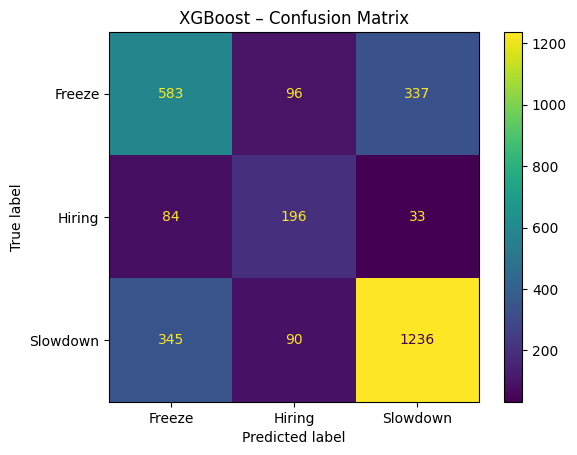

In [12]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=le.classes_
)
plt.title("XGBoost – Confusion Matrix")
plt.show()

## 11. Feature Importance

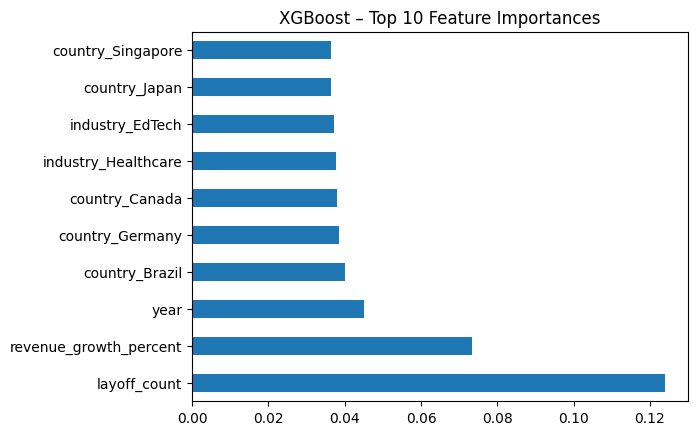

In [13]:
importance = pd.Series(best_xgb.feature_importances_, index=X.columns)

importance.nlargest(10).plot(kind='barh')
plt.title("XGBoost – Top 10 Feature Importances")
plt.show()

## 12. Model Comparison Summary

> XGBoost is a strong gradient boosting alternative explored by the team.
> After comparing all models, **Random Forest** achieves the highest accuracy and is selected for the HireSafe production system.

In [14]:
# Reference accuracy from Random Forest (hiresafe_main.ipynb)
rf_accuracy = 0.92  # update with actual value from hiresafe_main

comparison = pd.DataFrame({
    "Model": ["XGBoost", "Random Forest (Production)"],
    "Accuracy": [round(xgb_accuracy, 4), rf_accuracy]
})

print(comparison.to_string(index=False))
print("\n✅ Random Forest selected as the best model for production.")

                     Model  Accuracy
                   XGBoost    0.6717
Random Forest (Production)    0.9200

✅ Random Forest selected as the best model for production.
